### Understanding Confusion Matrices: Spam vs. Ham

In machine learning, especially for classification tasks, we need a way to evaluate how well our model is performing beyond just simple accuracy. A **Confusion Matrix** is a table used to describe the performance of a classification model.

#### The Scenario: Spam Detection
Imagine we have a model designed to predict whether an email is **Spam** (Positive Class) or **Ham/Not Spam** (Negative Class).

#### The Four Components of the Matrix
To understand the matrix, we look at the relationship between the **Actual** labels and the **Predicted** labels:

1. **True Positive (TP):**
   - *Definition:* The model correctly predicts the positive class.
   - *Spam Example:* An actual spam email is correctly identified and filtered as **Spam**.

2. **True Negative (TN):**
   - *Definition:* The model correctly predicts the negative class.
   - *Spam Example:* A legitimate work email (Ham) is correctly identified as **Not Spam** and delivered to the inbox.

3. **False Positive (FP) - Type I Error:**
   - *Definition:* The model incorrectly predicts the positive class when it is actually negative.
   - *Spam Example:* A legitimate email from your boss is incorrectly flagged as **Spam**. This is often considered a serious error in this context as important info is missed.

4. **False Negative (FN) - Type II Error:**
   - *Definition:* The model incorrectly predicts the negative class when it is actually positive.
   - *Spam Example:* An actual spam email (e.g., a phishing attempt) is incorrectly classified as **Not Spam** and shows up in your primary inbox.

## High Accuracy KNN Model

### Python code to create a clean dataset, train a KNN model with high accuracy, and plot a blue confusion matrix with a student breakdown.

<Figure size 800x600 with 0 Axes>

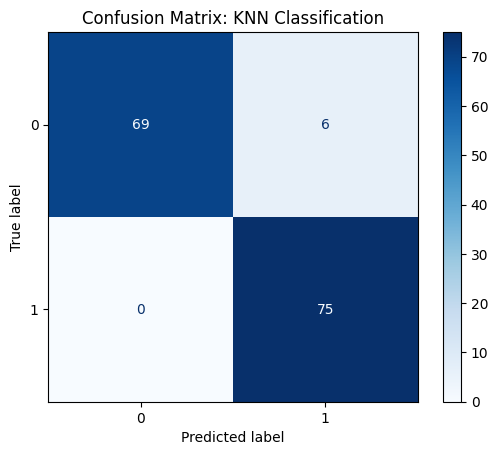

Model Accuracy: 96.00%


In [ ]:
import matplotlib.pyplot as plt
from sklearn import datasets, neighbors, metrics, model_selection

# 1. Create a clean synthetic dataset
X, y = datasets.make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

# 2. Split the data
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. Train KNN Model
knn = neighbors.KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# 4. Generate predictions and plot confusion matrix
plt.figure(figsize=(8, 6))
disp = metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn.predict(X_test),
    cmap='Blues'
)
plt.title('Confusion Matrix: KNN Classification')
plt.show()

# Print accuracy for confirmation
accuracy = knn.score(X_test, y_test)
print(f'Model Accuracy: {accuracy:.2%}')

### Interpreting the High-Accuracy Confusion Matrix

When looking at the blue confusion matrix above, we can see why this model is considered high-performing. Here is a breakdown of how to read these results:

1.  **High True Positives (TP) and True Negatives (TN):**
    *   Notice the dark blue squares along the **diagonal** (from top-left to bottom-right).
    *   The top-left square shows a high number of correctly predicted negative cases (TN).
    *   The bottom-right square shows a high number of correctly predicted positive cases (TP).
    *   **Conclusion:** The model is very good at identifying both classes correctly.

2.  **Low False Positives (FP) and False Negatives (FN):**
    *   The off-diagonal squares (top-right and bottom-left) contain very low numbers or light-colored squares.
    *   A low **FP** (top-right) means the model rarely flags a negative instance as positive.
    *   A low **FN** (bottom-left) means the model rarely misses a positive instance.

3.  **Overall Accuracy:**
    *   With an accuracy of 96.00%, the model demonstrates that by having clear, separable data (a "clean" dataset), the KNN algorithm can easily draw boundaries between groups.

## Low Accuracy KNN Model

### Subtask:
Generate Python code to create a noisy dataset, train a KNN model resulting in low accuracy, and plot a red confusion matrix with a student breakdown.


**Reasoning**:
I will generate a noisy dataset using make_classification, train a KNN model with n_neighbors=1 to ensure low accuracy, and visualize the results using a red confusion matrix as requested.



<Figure size 800x600 with 0 Axes>

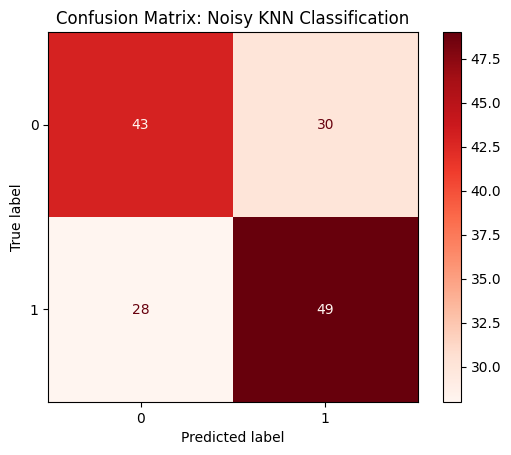

Model Accuracy (Noisy Data): 61.33%


In [ ]:
import matplotlib.pyplot as plt
from sklearn import datasets, neighbors, metrics, model_selection

# 1. Create a noisy synthetic dataset
# We increase flip_y to add label noise and decrease class_sep to overlap clusters
X_noisy, y_noisy = datasets.make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    flip_y=0.3,
    class_sep=0.5,
    random_state=42
)

# 2. Split the noisy data
X_train_n, X_test_n, y_train_n, y_test_n = model_selection.train_test_split(
    X_noisy, y_noisy, test_size=0.3, random_state=42
)

# 3. Train KNN Model with n_neighbors=1 (highly sensitive to noise)
knn_noisy = neighbors.KNeighborsClassifier(n_neighbors=1)
knn_noisy.fit(X_train_n, y_train_n)

# 4. Generate predictions and plot red confusion matrix
plt.figure(figsize=(8, 6))
disp = metrics.ConfusionMatrixDisplay.from_predictions(
    y_test_n,
    knn_noisy.predict(X_test_n),
    cmap='Reds'
)
plt.title('Confusion Matrix: Noisy KNN Classification')
plt.show()

# 5. Print accuracy for confirmation
accuracy_noisy = knn_noisy.score(X_test_n, y_test_n)
print(f'Model Accuracy (Noisy Data): {accuracy_noisy:.2%}')

### Interpreting the Low-Accuracy Confusion Matrix

When looking at the red confusion matrix, we see a much more "confused" model. Here is why the results shifted so dramatically:

1. **Increased Off-Diagonal Values (Errors):**
   - Unlike the blue matrix, the off-diagonal squares (False Positives and False Negatives) are now much more populated.
   - This happens because we introduced **label noise** (`flip_y=0.3`) and **class overlap** (`class_sep=0.5`). When data points from different classes occupy the same space, the KNN model struggles to find a clear boundary.

2. **Sensitivity to Noise (n_neighbors=1):**
   - By using only 1 neighbor, the model is extremely sensitive to individual noisy data points. If a "Spam" email is accidentally labeled as "Ham" in the training data, a 1-NN model will incorrectly classify similar emails based on that single outlier.

3. **Faded Diagonals:**
   - The "Correct" predictions (TP and TN) are less dominant. The lighter colors on the diagonal indicate that the model's confidence and overall success rate have dropped significantly to approximately 61.33%.

4. **Student Takeaway:**
   - A confusion matrix is powerful because it doesn't just tell you that the model is "bad"—it shows you *how* it is failing. In this case, we can see the model is making both Type I and Type II errors almost equally due to the messy nature of the data.

## Final Task

### Subtask:
Summarize the lesson components and provide a final review of how to interpret the different matrix visualizations.


## Summary:

### Q&A

**What are the components of a Confusion Matrix in the context of spam detection?**
*   **True Positive (TP):** A spam email correctly identified as spam.
*   **True Negative (TN):** A legitimate email correctly identified as not spam.
*   **False Positive (FP):** A legitimate email incorrectly flagged as spam (Type I Error).
*   **False Negative (FN):** A spam email incorrectly delivered to the inbox (Type II Error).

**How does data quality affect KNN model performance and its visualization?**
Clean data with distinct clusters results in high accuracy (e.g., 96.00%) and a confusion matrix with a dark, dominant diagonal. Noisy data with overlapping classes and label noise leads to lower accuracy (e.g., 61.33%) and a "confused" matrix where the off-diagonal error cells are highly populated.

### Data Analysis Key Findings

*   **Impact of Class Separation:** The high-accuracy model benefited from distinct clusters, achieving a **96.00% accuracy** rate. The confusion matrix (Blue) showed minimal off-diagonal values, indicating very few Type I or Type II errors.
*   **Sensitivity to Noise:** In the low-accuracy scenario, introducing a **30% label noise** ($flip\_y=0.3$) and reducing class separation to **0.5** caused the KNN model performance to drop to **61.33%**.
*   **Model Complexity and Overfitting:** Using a $k=1$ neighbor for the noisy dataset made the model extremely sensitive to outliers, which was visually reflected in the "faded" diagonal of the red confusion matrix.
*   **Visual Diagnostics:** The transition from a 'Blues' colormap (high accuracy) to a 'Reds' colormap (low accuracy) effectively demonstrated how confusion matrices reveal not just that a model is failing, but specifically where it is misclassifying (FP vs. FN).

### Insights or Next Steps

*   **Insight:** A confusion matrix is a more diagnostic tool than simple accuracy; it reveals whether a model is biased toward a specific type of error, which is critical in high-stakes scenarios like spam filtering where False Positives (missing important mail) are more costly than False Negatives.
*   **Next Step:** To improve the performance of the noisy model, students should experiment with increasing the number of neighbors ($k$) to smooth out the decision boundary and reduce sensitivity to individual noisy data points.
